In [7]:
import pandas as pd

# Load files
sales = pd.read_csv(r"D:\Downloads\Retails Analytics Project\Raw Data\salesdata.csv")
customers = pd.read_csv(r"D:\Downloads\Retails Analytics Project\Raw Data\customers.csv")
products = pd.read_csv(r"D:\Downloads\Retails Analytics Project\Raw Data\products.csv")
stores = pd.read_csv(r"D:\Downloads\Retails Analytics Project\Raw Data\stores.csv")
returns = pd.read_csv(r"D:\Downloads\Retails Analytics Project\Raw Data\returns.csv")

# Preview
print("SALES")
display(sales.head())

print("CUSTOMERS")
display(customers.head())

print("PRODUCTS")
display(products.head())

print("STORES")
display(stores.head())

print("RETURNS")
display(returns.head())

SALES


,order_id,order_date,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,total_amount
0,O00000,31-01-2025,C0125,P1086,NaN,Online,2,80.63,0.05,153.20
1,O00001,29-09-2025,C0633,P0973,S042,In-Store,20,209.16,0.05,3974.00
2,O00002,29-08-2024,C0653,P0659,NaN,Online,2,218.60,0.10,393.48
3,O00003,13-05-2025,C0753,P0666,S014,In-Store,1,78.53,0.20,62.82
4,O00004,22-07-2025,C0627,P0166,S017,In-Store,1,344.93,0.20,275.94


CUSTOMERS


,customer_id,first_name,last_name,gender,age,signup_date,region
0,C0000,Patrick,Morgan,Male,18.0,11-07-2025,South
1,C0001,Eric,Lee,Other,36.0,20-09-2021,East
2,C0002,Thomas,Pena,Female,NaN,07-03-2022,East
3,C0003,Dalton,Duran,Male,24.0,29-08-2022,South
4,C0004,Travis,Mcclain,Male,50.0,29-03-2024,South


PRODUCTS


,product_id,product_name,category,brand,cost_price,unit_price,margin_pct
0,P0000,BrandA Shoulder,Electronics,BrandC,52.75,64.65,18.41
1,P0001,BrandA Responsibility,Electronics,BrandD,11.20,13.26,15.54
2,P0002,BrandB Small,Electronics,BrandB,144.62,250.37,42.24
3,P0003,BrandD Continue,Apparel,BrandD,119.91,219.25,45.31
4,P0004,BrandA Indeed,Apparel,BrandD,71.35,88.47,19.35


STORES


,store_id,store_name,store_type,region,city,operating_cost
0,S000,Vincent Inc Store,Franchise,West,Chicago,62538.56
1,S001,Wilson Inc Store,Flagship,East,Chicago,26957.43
2,S002,Washington-Trujillo Store,Franchise,North,Los Angeles,66101.63
3,S003,Santana and Sons Store,Franchise,South,Phoenix,71089.40
4,S004,Oconnor-Rhodes Store,Franchise,East,Los Angeles,40965.26


RETURNS


,return_id,order_id,return_date,return_reason
0,R0000,O02237,05-03-2025,Defective
1,R0001,O01700,18-03-2025,Defective
2,R0002,O01451,18-02-2025,Late Delivery
3,R0003,O02759,26-10-2024,Defective
4,R0004,O00415,06-08-2025,No Longer Needed


In [8]:
def data_overview(df, name):
    print(f"\n===== {name} =====")
    print("Shape:", df.shape)
    print("\nColumns & Data Types:")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())

data_overview(sales, "SALES")
data_overview(customers, "CUSTOMERS")
data_overview(products, "PRODUCTS")
data_overview(stores, "STORES")
data_overview(returns, "RETURNS")


===== SALES =====
Shape: (3060, 10)

Columns & Data Types:
order_id          object
order_date        object
customer_id       object
product_id        object
store_id          object
sales_channel     object
quantity           int64
unit_price       float64
discount_pct     float64
total_amount     float64
dtype: object

Missing Values:
order_id           0
order_date         0
customer_id        0
product_id         0
store_id         992
sales_channel      0
quantity           0
unit_price         0
discount_pct       0
total_amount       0
dtype: int64

Duplicates: 60

===== CUSTOMERS =====
Shape: (816, 7)

Columns & Data Types:
customer_id     object
first_name      object
last_name       object
gender          object
age            float64
signup_date     object
region          object
dtype: object

Missing Values:
customer_id     0
first_name      0
last_name       0
gender          0
age            40
signup_date     0
region          0
dtype: int64

Duplicates: 16

===== PROD

In [9]:
sales['order_date'] = pd.to_datetime(sales['order_date'], dayfirst=True, errors='coerce')
customers['signup_date'] = pd.to_datetime(customers['signup_date'], dayfirst=True, errors='coerce')
returns['return_date'] = pd.to_datetime(returns['return_date'], dayfirst=True, errors='coerce')

In [10]:
sales['order_date'].isnull().sum()

np.int64(5)

In [11]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       3060 non-null   object        
 1   order_date     3055 non-null   datetime64[ns]
 2   customer_id    3060 non-null   object        
 3   product_id     3060 non-null   object        
 4   store_id       2068 non-null   object        
 5   sales_channel  3060 non-null   object        
 6   quantity       3060 non-null   int64         
 7   unit_price     3060 non-null   float64       
 8   discount_pct   3060 non-null   float64       
 9   total_amount   3060 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 239.2+ KB


In [12]:
sales = sales.dropna(subset=['order_date'])

In [16]:
# total_amount
sales['total_amount'] = sales['unit_price'] * sales['quantity'] * (1 - sales['discount_pct'])

# merge cost_price safely
sales = sales.merge(
    products[['product_id', 'cost_price']],
    on='product_id',
    how='left',
    suffixes=('', '_prod')
)

# If merge created cost_price_prod
if 'cost_price_prod' in sales.columns:
    sales['cost_price'] = sales['cost_price_prod']
    sales.drop(columns=['cost_price_prod'], inplace=True)

# Profit
sales['profit'] = sales['total_amount'] - (sales['cost_price'] * sales['quantity'])

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='year_month'>

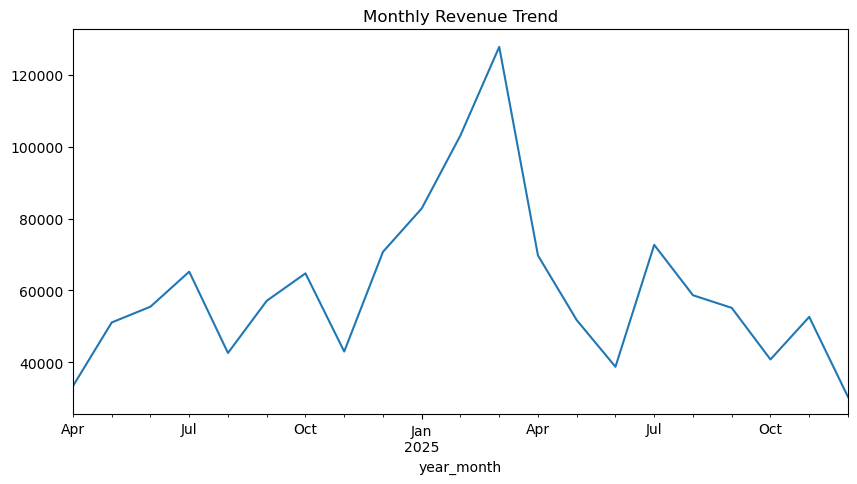

In [18]:
sales['year_month'] = sales['order_date'].dt.to_period('M')

monthly_revenue = sales.groupby('year_month')['total_amount'].sum()

monthly_revenue.plot(figsize=(10,5), title="Monthly Revenue Trend")

In [19]:
print(sales.columns)

Index(['order_id', 'order_date', 'customer_id', 'product_id', 'store_id',
       'sales_channel', 'quantity', 'unit_price', 'discount_pct',
       'total_amount', 'cost_price_x', 'cost_price_y', 'cost_price', 'profit',
       'year_month'],
      dtype='object')


In [20]:
sales.rename(columns={'cost_price_y':'cost_price'}, inplace=True)

In [24]:
# Remove duplicate cost columns if they exist
sales = sales.loc[:, ~sales.columns.duplicated()].copy()

# Drop extra cost_price columns
sales.drop(columns=['cost_price_x'], inplace=True, errors='ignore')

# Rename cost_price_y if it exists
if 'cost_price_y' in sales.columns:
    sales.rename(columns={'cost_price_y': 'cost_price'}, inplace=True)

In [25]:
bins = [0,18,25,35,50,65,100]
labels = ['Teen','Young Adult','Adult','Mid Age','Senior','Old']

customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels)

In [26]:
# calculate revenue
sales['revenue'] = sales['unit_price'] * sales['quantity'] * (1 - sales['discount_pct'])

# replace total_amount with the calculated value
sales['total_amount'] = sales['revenue']

# remove revenue column
sales.drop(columns=['revenue'], inplace=True)
sales.drop(columns=['cost_price_x'], inplace=True, errors='ignore')

In [27]:
sales.to_csv("sales_cleaned.csv", index=False)
customers.to_csv("customers_cleaned.csv", index=False)
products.to_csv("products_cleaned.csv", index=False)
stores.to_csv("stores_cleaned.csv", index=False)
returns.to_csv("returns_cleaned.csv", index=False)